<!--<badge>--><a href="https://colab.research.google.com/github/JoeChen322/Fintech/blob/main/classification-dl-models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a><!--</badge>-->


# Deep Learning for Investment Product Classification


## Imports & Dependencies


In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
import gdown

url = "https://drive.google.com/uc?id=1TiR645keulkG4pONLpVn-bO4elNBtNpX"
file_path = "Dataset2_Needs.xls"
gdown.download(url, file_path, quiet=False)
df = pd.read_excel("Dataset2_Needs.xls", sheet_name="Needs")

%config InlineBackend.figure_format = 'retina'

Downloading...
From: https://drive.google.com/uc?id=1TiR645keulkG4pONLpVn-bO4elNBtNpX
To: /Users/pengrao/Workspace/Fintech/Dataset2_Needs.xls
100%|██████████| 428k/428k [00:00<00:00, 4.82MB/s]


# Dataset


In [26]:
class FinancialNeedsDataset(Dataset):
    def __init__(self, df):
        # Log and scale continuous features
        self.cont_cols = [
            "Age",
            "FinancialEducation",
            "RiskPropensity",
            "Income",
            "Wealth",
        ]

        df["Income"] = np.log1p(df["Income"])
        df["Wealth"] = np.log1p(df["Wealth"])

        self.scaler = StandardScaler()
        self.X_cont = self.scaler.fit_transform(df[self.cont_cols].values)
        self.X_cont = torch.tensor(self.X_cont, dtype=torch.float32)

        # Encode categorical features
        self.cat_cols = ["Gender", "FamilyMembers"]
        self.X_cat = np.zeros((len(df), len(self.cat_cols)))
        self.cat_dims = []

        for i, col in enumerate(self.cat_cols):
            le = LabelEncoder()
            self.X_cat[:, i] = le.fit_transform(df[col].values)
            self.cat_dims.append(len(le.classes_))

        self.X_cat = torch.tensor(self.X_cat, dtype=torch.long)

        # targets
        self.y_income = torch.tensor(df["IncomeInvestment"].values, dtype=torch.float32)
        self.y_accum = torch.tensor(
            df["AccumulationInvestment"].values, dtype=torch.float32
        )

    def __len__(self):
        return len(self.y_income)

    def __getitem__(self, idx):
        return self.X_cat[idx], self.X_cont[idx], self.y_income[idx], self.y_accum[idx]

In [27]:
dataset = FinancialNeedsDataset(df)
train_loader = DataLoader(dataset, batch_size=256, shuffle=True)

# Network Architecture


In [28]:
class CrossNetwork(nn.Module):
    """ """

    def __init__(self, input_dim, num_layers):
        super(CrossNetwork, self).__init__()
        self.num_layers = num_layers
        self.cross_weights = nn.ParameterList(
            [nn.Parameter(torch.randn(input_dim)) for _ in range(num_layers)]
        )
        self.cross_biases = nn.ParameterList(
            [nn.Parameter(torch.zeros(input_dim)) for _ in range(num_layers)]
        )

    def forward(self, x_0):
        x_l = x_0
        for i in range(self.num_layers):
            xw = torch.sum(x_l * self.cross_weights[i], dim=1, keepdim=True)
            x_l = x_0 * xw + self.cross_biases[i] + x_l
        return x_l


class DCN(nn.Module):
    def __init__(
        self, cat_dims, cont_dim, embed_dim=4, cross_layers=3, deep_layers=[64, 32]
    ):
        super(DCN, self).__init__()

        self.embeddings = nn.ModuleList(
            [
                nn.Embedding(num_embeddings=dim, embedding_dim=embed_dim)
                for dim in cat_dims
            ]
        )

        self.input_dim = len(cat_dims) * embed_dim + cont_dim

        self.cross_net = CrossNetwork(self.input_dim, cross_layers)

        deep_modules = []
        in_dim = self.input_dim
        for out_dim in deep_layers:
            deep_modules.append(nn.Linear(in_dim, out_dim))
            deep_modules.append(nn.BatchNorm1d(out_dim))
            deep_modules.append(nn.ReLU())
            deep_modules.append(nn.Dropout(0.3))
            in_dim = out_dim
        self.deep_net = nn.Sequential(*deep_modules)

        concat_dim = self.input_dim + deep_layers[-1]
        self.fc_out = nn.Linear(concat_dim, 1)

    def forward(self, x_cat, x_cont):
        embeds = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        embed_out = torch.cat(embeds, dim=1)

        x_0 = torch.cat([embed_out, x_cont], dim=1)

        cross_out = self.cross_net(x_0)
        deep_out = self.deep_net(x_0)

        concat_out = torch.cat([cross_out, deep_out], dim=1)
        logits = self.fc_out(concat_out)
        return logits

# Train/Validation/Test Split


In [29]:
from sklearn.model_selection import train_test_split

n_samples = len(dataset)
indices = np.arange(n_samples)

# 70% train, 15% validation, 15% test
train_idx, temp_idx = train_test_split(indices, test_size=0.3, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42)

print(f"Train set size: {len(train_idx)} ({len(train_idx) / n_samples * 100:.1f}%)")
print(f"Validation set size: {len(val_idx)} ({len(val_idx) / n_samples * 100:.1f}%)")
print(f"Test set size: {len(test_idx)} ({len(test_idx) / n_samples * 100:.1f}%)")

from torch.utils.data import Subset

train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)
test_dataset = Subset(dataset, test_idx)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

Train set size: 3500 (70.0%)
Validation set size: 750 (15.0%)
Test set size: 750 (15.0%)


# Evaluation Metrics & Functions


In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
)
import matplotlib.pyplot as plt
import seaborn as sns

# Set up visualization style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)


def evaluate_model(model, data_loader, dataset_name="Test"):
    """
    Evaluate model on a dataset and return metrics for both tasks.
    Returns: all_predictions, all_probs, all_labels
    """
    model.eval()

    all_preds_income = []
    all_preds_accum = []
    all_probs_income = []
    all_probs_accum = []
    all_labels_income = []
    all_labels_accum = []

    with torch.no_grad():
        for x_cat, x_cont, y_inc, y_acc in data_loader:
            # Income Investment predictions
            logits_inc = model_income(x_cat, x_cont).squeeze()
            probs_inc = torch.sigmoid(logits_inc)
            preds_inc = (probs_inc > 0.5).long()

            # Accumulation Investment predictions
            logits_acc = model_accum(x_cat, x_cont).squeeze()
            probs_acc = torch.sigmoid(logits_acc)
            preds_acc = (probs_acc > 0.5).long()

            all_preds_income.extend(preds_inc.cpu().numpy())
            all_preds_accum.extend(preds_acc.cpu().numpy())
            all_probs_income.extend(probs_inc.cpu().numpy())
            all_probs_accum.extend(probs_acc.cpu().numpy())
            all_labels_income.extend(y_inc.numpy())
            all_labels_accum.extend(y_acc.numpy())

    return {
        "income": {
            "preds": np.array(all_preds_income),
            "probs": np.array(all_probs_income),
            "labels": np.array(all_labels_income),
        },
        "accum": {
            "preds": np.array(all_preds_accum),
            "probs": np.array(all_probs_accum),
            "labels": np.array(all_labels_accum),
        },
    }


def compute_metrics(labels, preds, probs):
    """
    Compute comprehensive classification metrics.
    """
    labels_int = labels.astype(int)
    preds_int = preds.astype(int)

    return {
        "accuracy": accuracy_score(labels_int, preds_int),
        "precision": precision_score(labels_int, preds_int, zero_division=0),
        "recall": recall_score(labels_int, preds_int, zero_division=0),
        "f1": f1_score(labels_int, preds_int, zero_division=0),
        "roc_auc": roc_auc_score(labels_int, probs),
        "confusion_matrix": confusion_matrix(labels_int, preds_int),
    }


def print_metrics(metrics, task_name, dataset_name="Test"):
    """
    Print metrics in a formatted way.
    """
    print(f"\n{task_name} - {dataset_name} Set Metrics:")
    print(f"  Accuracy:  {metrics['accuracy']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall:    {metrics['recall']:.4f}")
    print(f"  F1-Score:  {metrics['f1']:.4f}")
    print(f"  ROC-AUC:   {metrics['roc_auc']:.4f}")
    cm = metrics["confusion_matrix"]
    print(f"  Confusion Matrix:\n{cm}")


print("✓ Evaluation functions defined")

✓ Evaluation functions defined


# Training with Validation


In [31]:
cat_dims = dataset.cat_dims
cont_dim = len(dataset.cont_cols)

# Initialize models
model_income = DCN(
    cat_dims=cat_dims,
    cont_dim=cont_dim,
    embed_dim=4,
    cross_layers=2,
    deep_layers=[128, 64, 32],
)
model_accum = DCN(
    cat_dims=cat_dims,
    cont_dim=cont_dim,
    embed_dim=4,
    cross_layers=2,
    deep_layers=[128, 64, 32],
)

criterion = nn.BCEWithLogitsLoss()

optimizer_income = optim.Adam(model_income.parameters(), lr=0.005, weight_decay=1e-4)
optimizer_accum = optim.Adam(model_accum.parameters(), lr=0.005, weight_decay=1e-4)

# Training configuration
num_epochs = 200
best_val_f1_income = 0
best_val_f1_accum = 0
patience = 30
patience_counter = 0

# Track history
history = {
    "train_loss_income": [],
    "train_loss_accum": [],
    "val_loss_income": [],
    "val_loss_accum": [],
    "val_f1_income": [],
    "val_f1_accum": [],
}

print("Starting training with validation...\n")

for epoch in range(num_epochs):
    # ===== Training Phase =====
    model_income.train()
    model_accum.train()

    loss_income_train = 0
    loss_accum_train = 0

    for x_cat, x_cont, y_inc, y_acc in train_loader:
        optimizer_income.zero_grad()
        optimizer_accum.zero_grad()

        logits_inc = model_income(x_cat, x_cont).squeeze()
        loss_inc = criterion(logits_inc, y_inc)
        loss_inc.backward()
        optimizer_income.step()

        logits_acc = model_accum(x_cat, x_cont).squeeze()
        loss_acc = criterion(logits_acc, y_acc)
        loss_acc.backward()
        optimizer_accum.step()

        loss_income_train += loss_inc.item()
        loss_accum_train += loss_acc.item()

    avg_train_loss_income = loss_income_train / len(train_loader)
    avg_train_loss_accum = loss_accum_train / len(train_loader)
    history["train_loss_income"].append(avg_train_loss_income)
    history["train_loss_accum"].append(avg_train_loss_accum)

    # ===== Validation Phase =====
    model_income.eval()
    model_accum.eval()

    loss_income_val = 0
    loss_accum_val = 0
    all_preds_inc_val = []
    all_preds_acc_val = []
    all_labels_inc_val = []
    all_labels_acc_val = []

    with torch.no_grad():
        for x_cat, x_cont, y_inc, y_acc in val_loader:
            logits_inc = model_income(x_cat, x_cont).squeeze()
            loss_inc = criterion(logits_inc, y_inc)
            loss_income_val += loss_inc.item()
            preds_inc = (torch.sigmoid(logits_inc) > 0.5).long()
            all_preds_inc_val.extend(preds_inc.cpu().numpy())
            all_labels_inc_val.extend(y_inc.numpy().astype(int))

            logits_acc = model_accum(x_cat, x_cont).squeeze()
            loss_acc = criterion(logits_acc, y_acc)
            loss_accum_val += loss_acc.item()
            preds_acc = (torch.sigmoid(logits_acc) > 0.5).long()
            all_preds_acc_val.extend(preds_acc.cpu().numpy())
            all_labels_acc_val.extend(y_acc.numpy().astype(int))

    avg_val_loss_income = loss_income_val / len(val_loader)
    avg_val_loss_accum = loss_accum_val / len(val_loader)

    val_f1_income = f1_score(all_labels_inc_val, all_preds_inc_val, zero_division=0)
    val_f1_accum = f1_score(all_labels_acc_val, all_preds_acc_val, zero_division=0)

    history["val_loss_income"].append(avg_val_loss_income)
    history["val_loss_accum"].append(avg_val_loss_accum)
    history["val_f1_income"].append(val_f1_income)
    history["val_f1_accum"].append(val_f1_accum)

    # Early stopping logic
    if val_f1_income > best_val_f1_income:
        best_val_f1_income = val_f1_income
        patience_counter = 0
    if val_f1_accum > best_val_f1_accum:
        best_val_f1_accum = val_f1_accum

    patience_counter += 1

    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{num_epochs}:")
        print(
            f"  Train Loss - Income: {avg_train_loss_income:.4f}, Accum: {avg_train_loss_accum:.4f}"
        )
        print(
            f"  Val Loss   - Income: {avg_val_loss_income:.4f}, Accum: {avg_val_loss_accum:.4f}"
        )
        print(f"  Val F1     - Income: {val_f1_income:.4f}, Accum: {val_f1_accum:.4f}")

    # Early stopping
    if patience_counter >= patience:
        print(
            f"\nEarly stopping at epoch {epoch + 1}. No improvement for {patience} epochs."
        )
        break

print("\nTraining complete!")

Starting training with validation...

Epoch 10/200:
  Train Loss - Income: 0.5022, Accum: 0.5239
  Val Loss   - Income: 0.4854, Accum: 0.4785
  Val F1     - Income: 0.6829, Accum: 0.7725
Epoch 20/200:
  Train Loss - Income: 0.4995, Accum: 0.4769
  Val Loss   - Income: 0.4845, Accum: 0.4748
  Val F1     - Income: 0.6776, Accum: 0.7801
Epoch 30/200:
  Train Loss - Income: 0.4945, Accum: 0.4718
  Val Loss   - Income: 0.4820, Accum: 0.4491
  Val F1     - Income: 0.6777, Accum: 0.7746
Epoch 40/200:
  Train Loss - Income: 0.4815, Accum: 0.4425
  Val Loss   - Income: 0.4765, Accum: 0.4338
  Val F1     - Income: 0.6802, Accum: 0.7956
Epoch 50/200:
  Train Loss - Income: 0.4800, Accum: 0.4502
  Val Loss   - Income: 0.4780, Accum: 0.4437
  Val F1     - Income: 0.6777, Accum: 0.7619
Epoch 60/200:
  Train Loss - Income: 0.4786, Accum: 0.4326
  Val Loss   - Income: 0.4803, Accum: 0.4373
  Val F1     - Income: 0.6734, Accum: 0.7837

Early stopping at epoch 61. No improvement for 30 epochs.

Training

# Test Set Evaluation


In [32]:
print("\n" + "=" * 80)
print("TEST SET EVALUATION")
print("=" * 80)

# Evaluate on test set
test_results = evaluate_model(model_income, test_loader, "Test")

# Compute metrics for both tasks
income_metrics = compute_metrics(
    test_results["income"]["labels"],
    test_results["income"]["preds"],
    test_results["income"]["probs"],
)

accum_metrics = compute_metrics(
    test_results["accum"]["labels"],
    test_results["accum"]["preds"],
    test_results["accum"]["probs"],
)

# Print detailed metrics
print_metrics(income_metrics, "Income Investment", "Test")
print_metrics(accum_metrics, "Accumulation Investment", "Test")

# Classification reports
print(f"\n{'=' * 80}")
print("Detailed Classification Report - Income Investment")
print(f"{'=' * 80}")
print(
    classification_report(
        test_results["income"]["labels"].astype(int),
        test_results["income"]["preds"],
        target_names=["No", "Yes"],
    )
)

print(f"\n{'=' * 80}")
print("Detailed Classification Report - Accumulation Investment")
print(f"{'=' * 80}")
print(
    classification_report(
        test_results["accum"]["labels"].astype(int),
        test_results["accum"]["preds"],
        target_names=["No", "Yes"],
    )
)


TEST SET EVALUATION

Income Investment - Test Set Metrics:
  Accuracy:  0.7827
  Precision: 0.8519
  Recall:    0.5439
  F1-Score:  0.6639
  ROC-AUC:   0.7671
  Confusion Matrix:
[[426  28]
 [135 161]]

Accumulation Investment - Test Set Metrics:
  Accuracy:  0.7947
  Precision: 0.8464
  Recall:    0.7077
  F1-Score:  0.7708
  ROC-AUC:   0.8519
  Confusion Matrix:
[[337  47]
 [107 259]]

Detailed Classification Report - Income Investment
              precision    recall  f1-score   support

          No       0.76      0.94      0.84       454
         Yes       0.85      0.54      0.66       296

    accuracy                           0.78       750
   macro avg       0.81      0.74      0.75       750
weighted avg       0.80      0.78      0.77       750


Detailed Classification Report - Accumulation Investment
              precision    recall  f1-score   support

          No       0.76      0.88      0.81       384
         Yes       0.85      0.71      0.77       366

    accu

# Visualizations


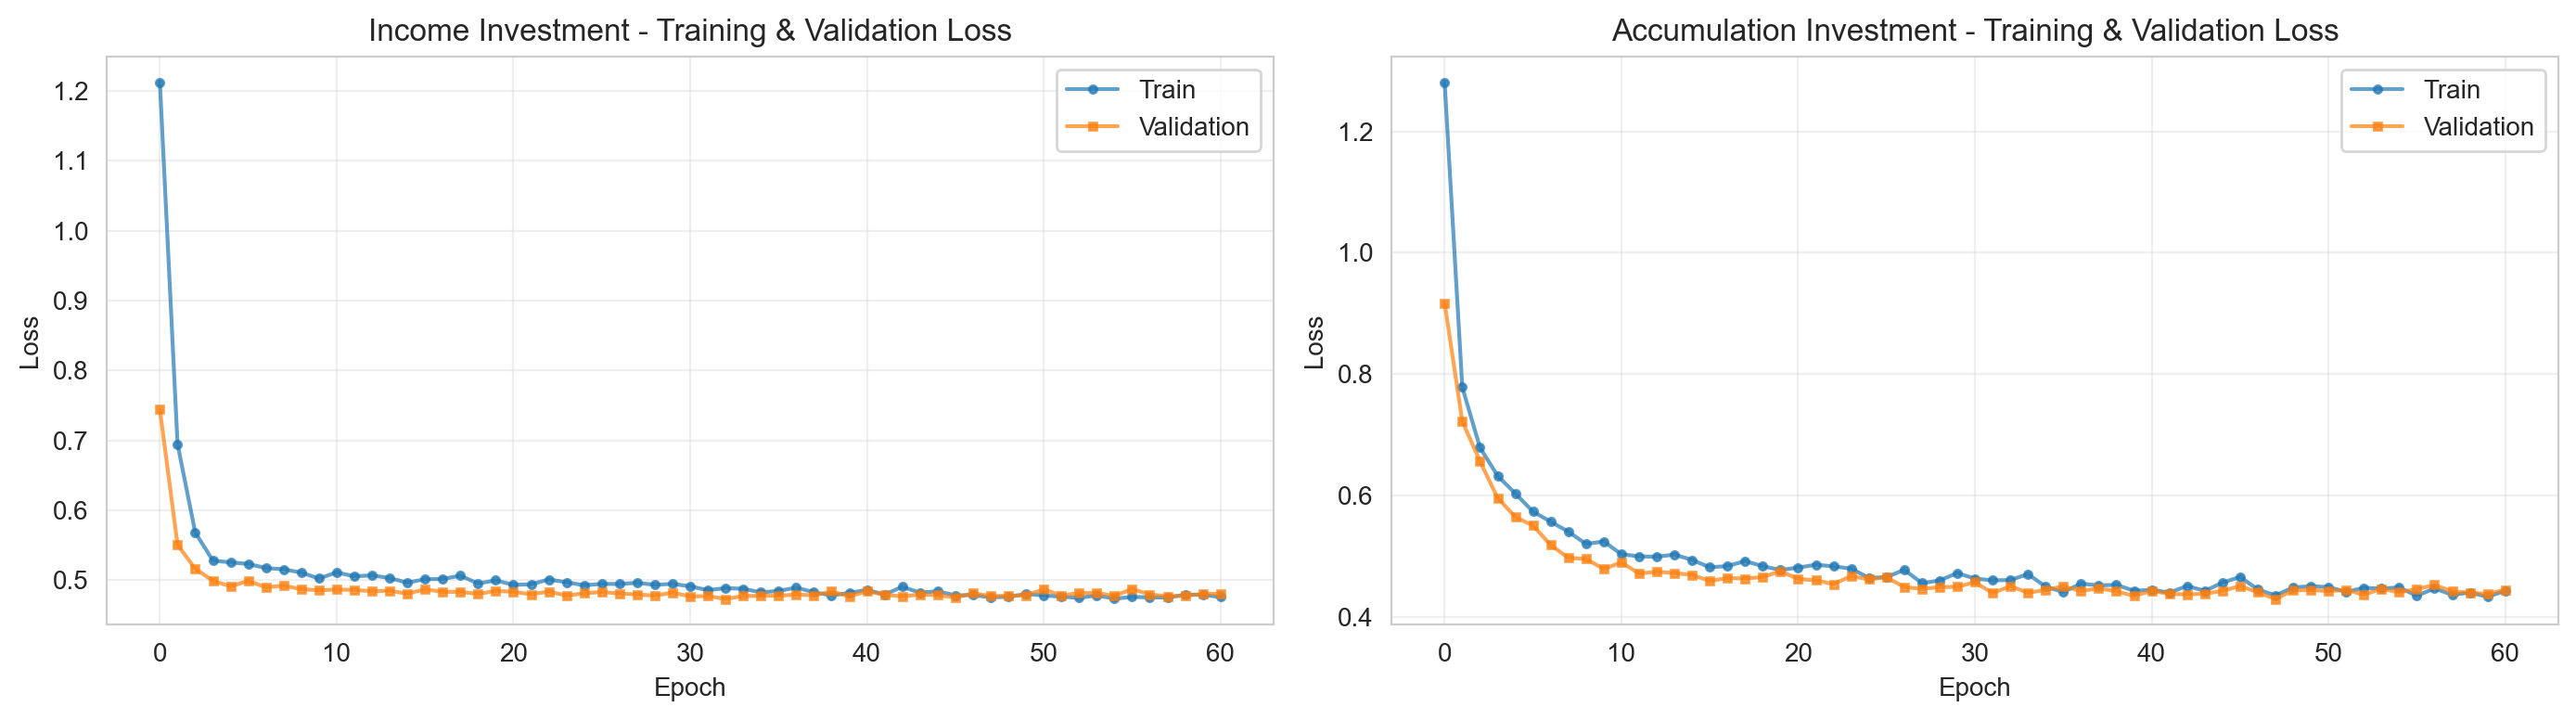

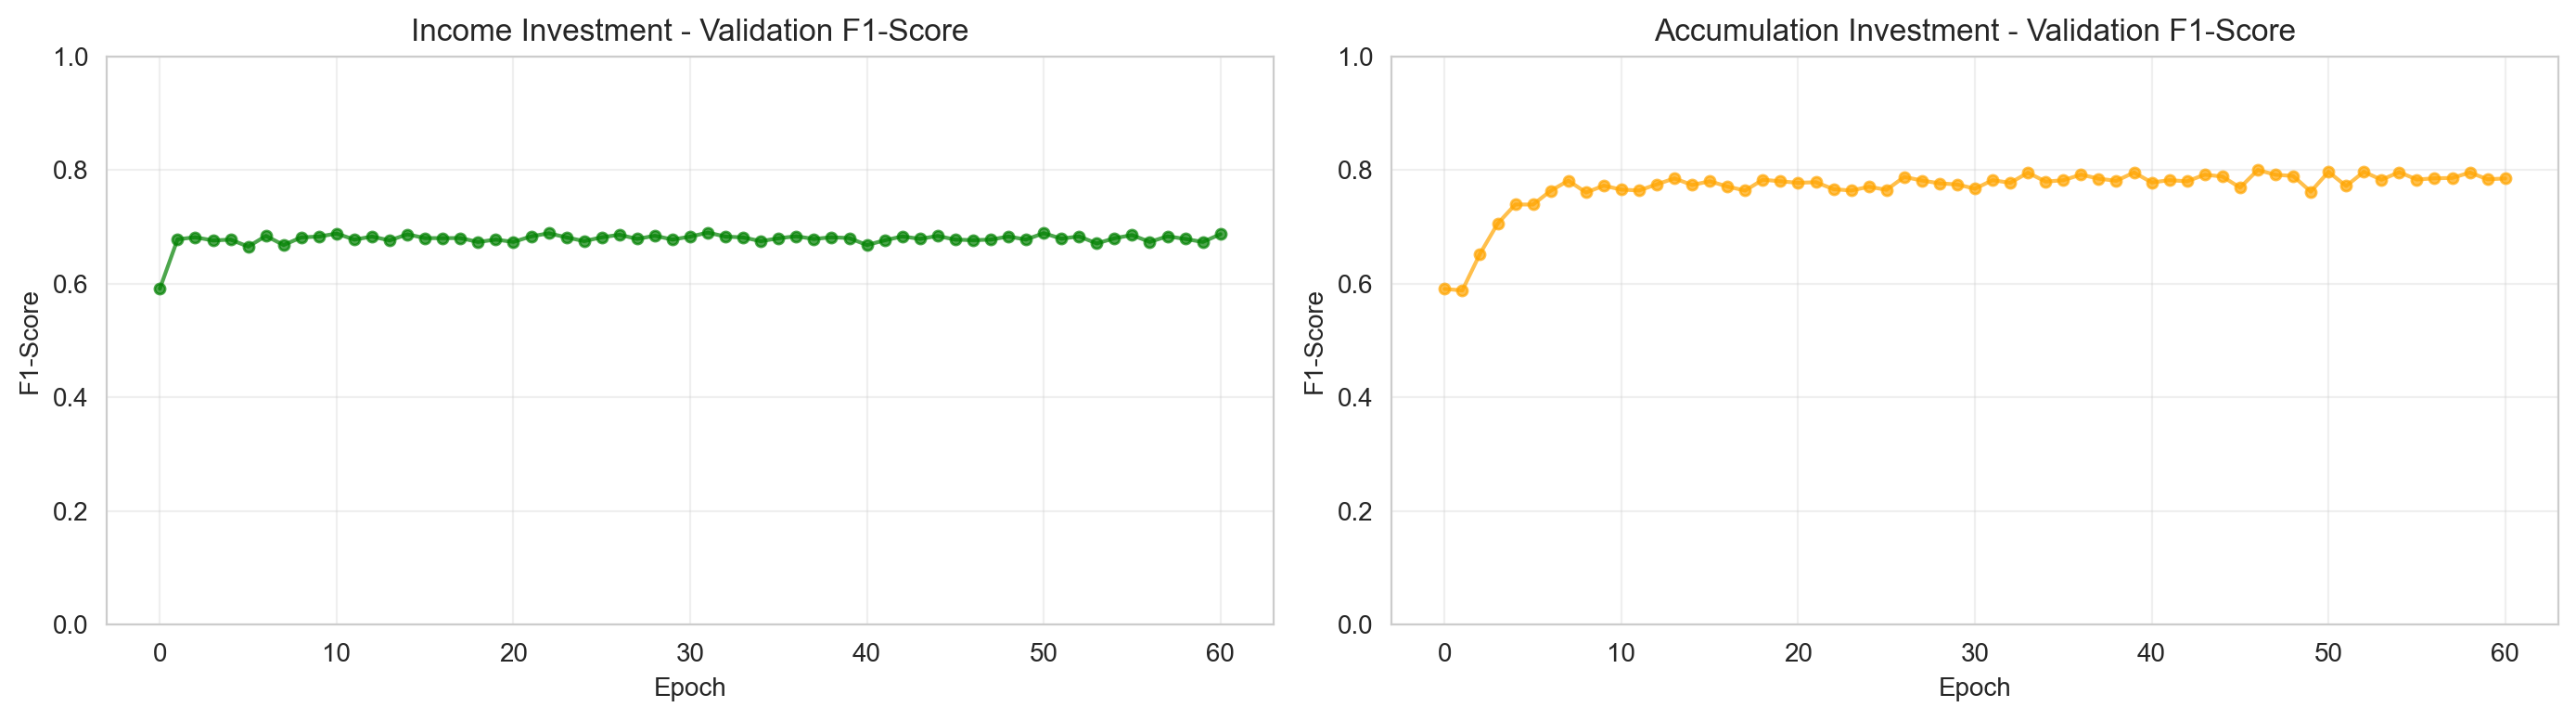

In [33]:
# 1. Training and Validation Loss Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(
    history["train_loss_income"], label="Train", marker="o", markersize=3, alpha=0.7
)
axes[0].plot(
    history["val_loss_income"], label="Validation", marker="s", markersize=3, alpha=0.7
)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Income Investment - Training & Validation Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    history["train_loss_accum"], label="Train", marker="o", markersize=3, alpha=0.7
)
axes[1].plot(
    history["val_loss_accum"], label="Validation", marker="s", markersize=3, alpha=0.7
)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Accumulation Investment - Training & Validation Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
import os

os.makedirs("figures", exist_ok=True)
plt.savefig("figures/loss_curves_dl.png", dpi=300, bbox_inches="tight")
plt.show()

# 2. Validation F1-Score Evolution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(
    history["val_f1_income"],
    label="F1-Score",
    marker="o",
    color="green",
    markersize=4,
    alpha=0.7,
)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("F1-Score")
axes[0].set_title("Income Investment - Validation F1-Score")
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1])

axes[1].plot(
    history["val_f1_accum"],
    label="F1-Score",
    marker="o",
    color="orange",
    markersize=4,
    alpha=0.7,
)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1-Score")
axes[1].set_title("Accumulation Investment - Validation F1-Score")
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig("figures/f1_scores_dl.png", dpi=300, bbox_inches="tight")
plt.show()

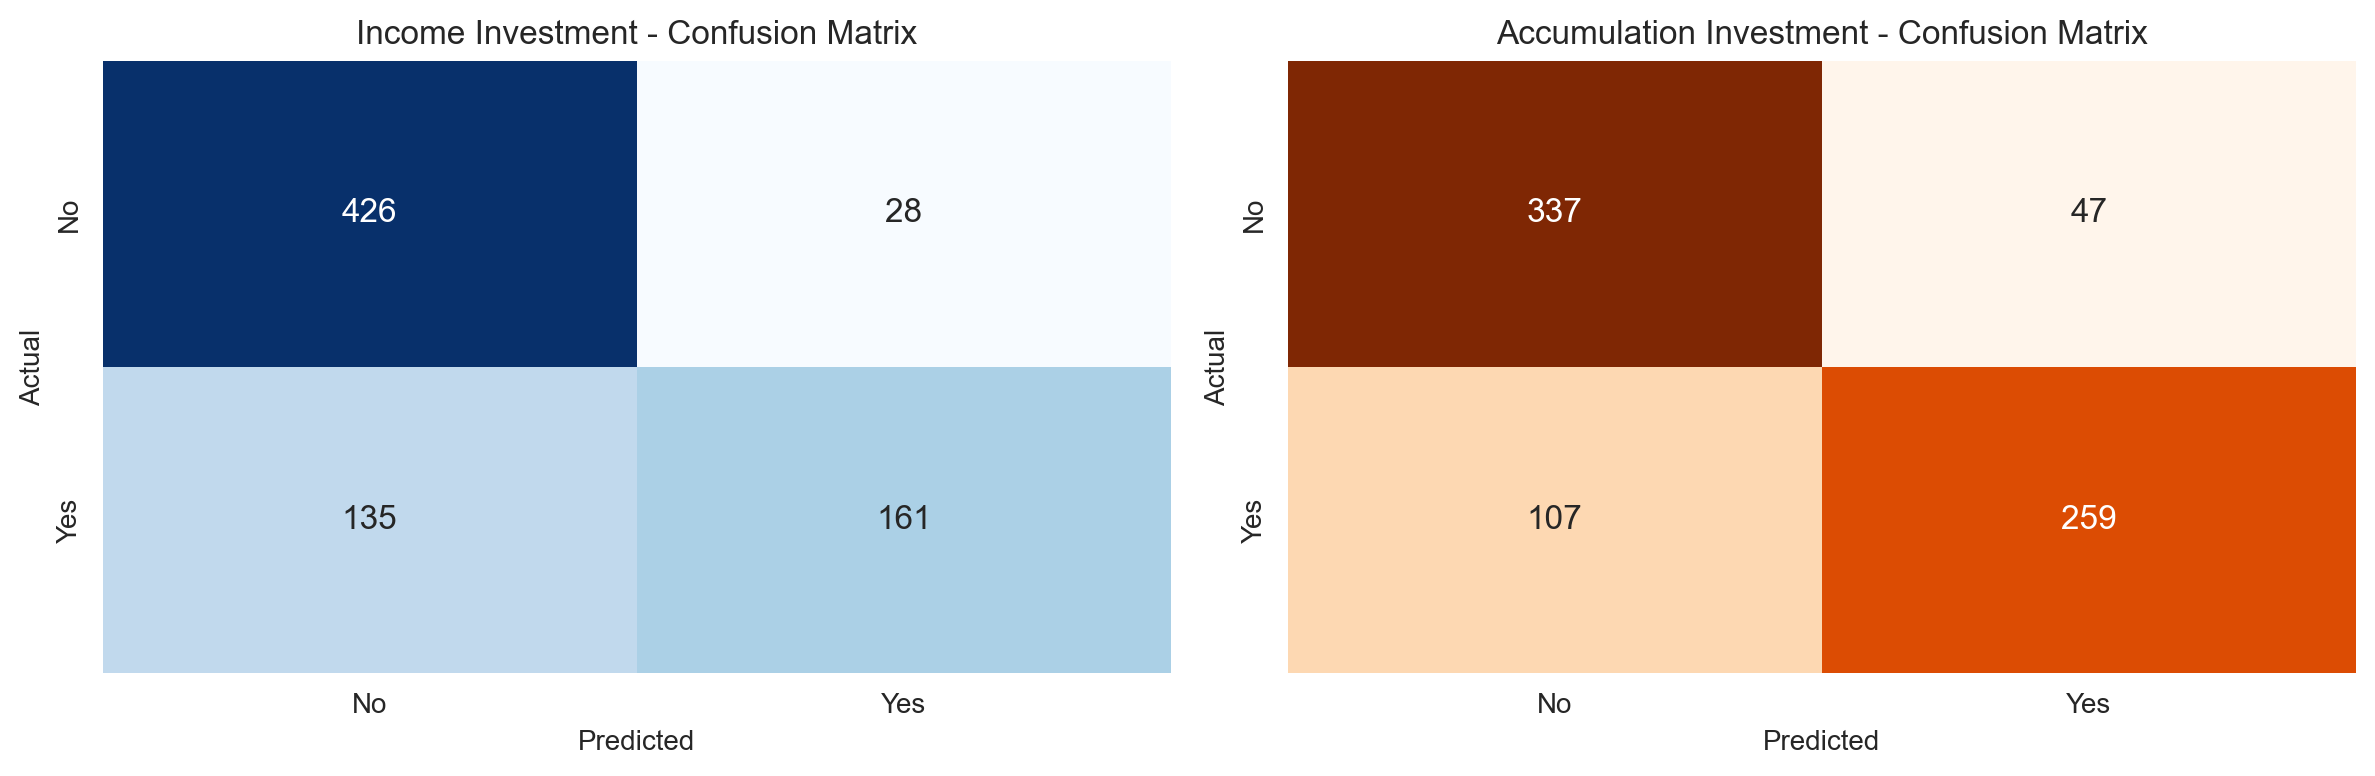

In [34]:
# 3. Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Income Investment
sns.heatmap(
    income_metrics["confusion_matrix"],
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    cbar=False,
    annot_kws={"size": 12},
)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("Income Investment - Confusion Matrix")
axes[0].set_xticklabels(["No", "Yes"])
axes[0].set_yticklabels(["No", "Yes"])

# Accumulation Investment
sns.heatmap(
    accum_metrics["confusion_matrix"],
    annot=True,
    fmt="d",
    cmap="Oranges",
    ax=axes[1],
    cbar=False,
    annot_kws={"size": 12},
)
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title("Accumulation Investment - Confusion Matrix")
axes[1].set_xticklabels(["No", "Yes"])
axes[1].set_yticklabels(["No", "Yes"])

plt.tight_layout()
plt.savefig("figures/confusion_matrices_dl.png", dpi=300, bbox_inches="tight")
plt.show()

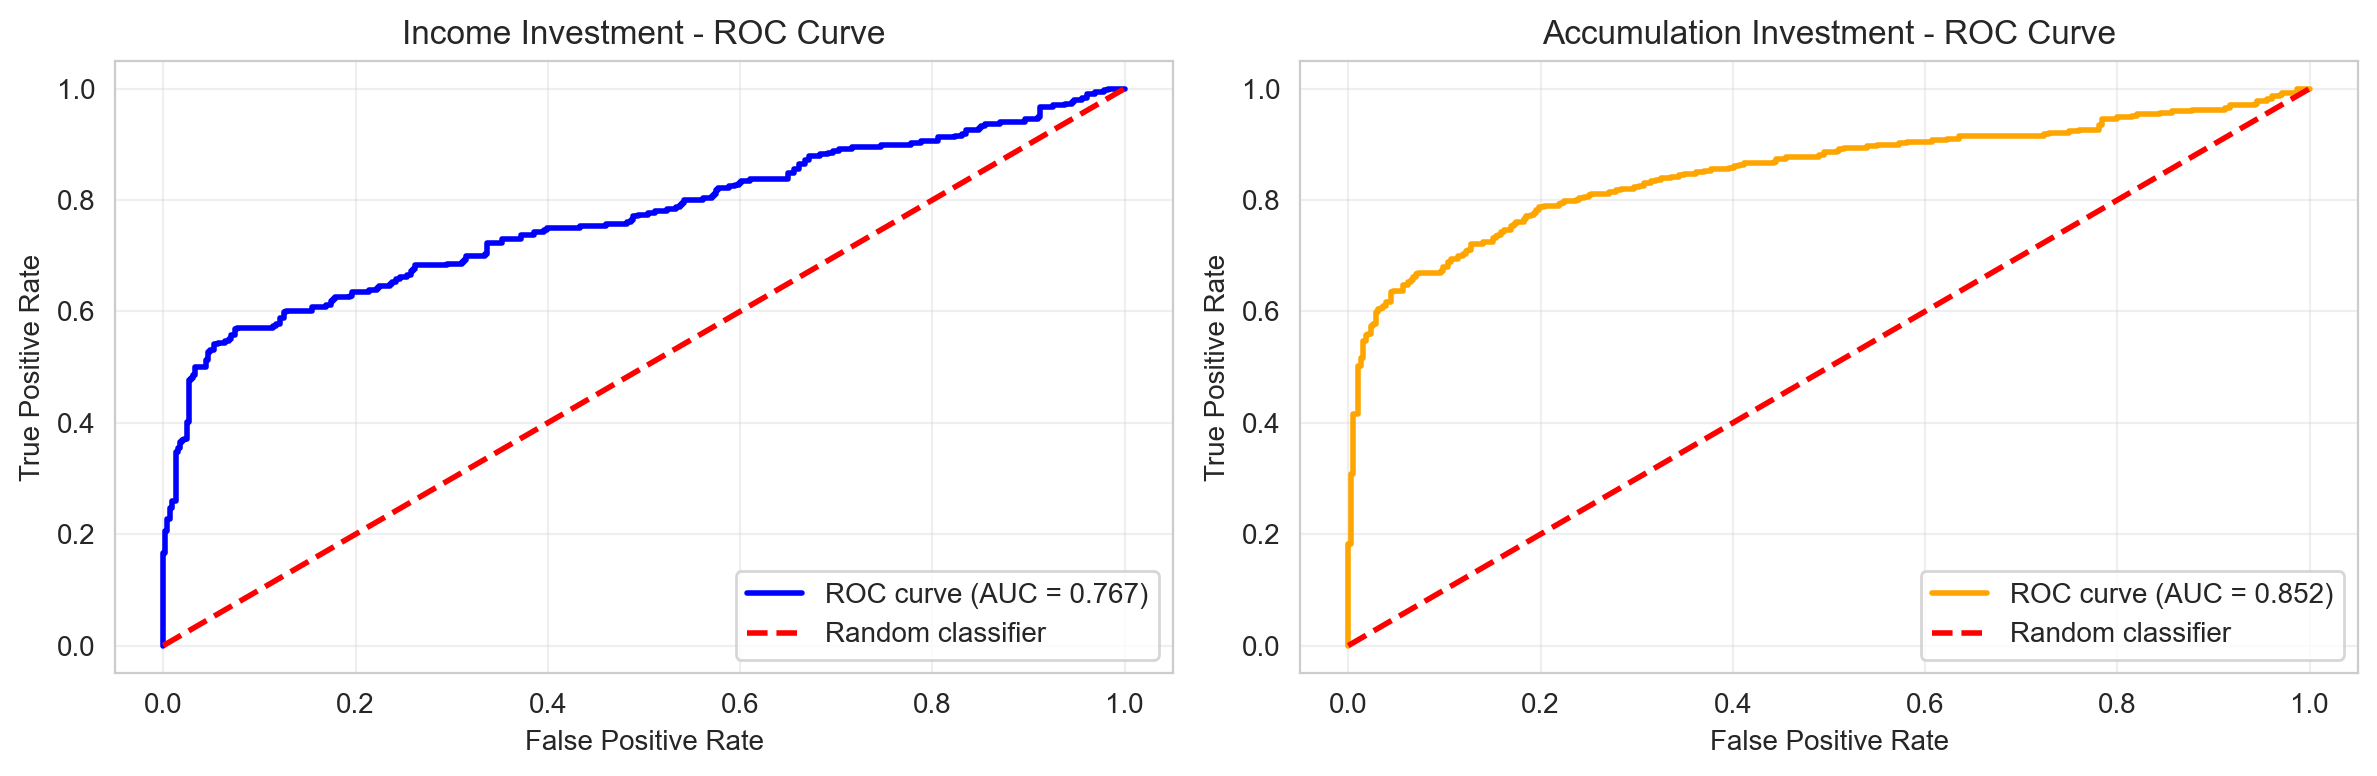

In [35]:
# 4. ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Income Investment ROC
fpr_inc, tpr_inc, _ = roc_curve(
    test_results["income"]["labels"].astype(int), test_results["income"]["probs"]
)
auc_inc = auc(fpr_inc, tpr_inc)

axes[0].plot(
    fpr_inc, tpr_inc, color="blue", lw=2, label=f"ROC curve (AUC = {auc_inc:.3f})"
)
axes[0].plot(
    [0, 1], [0, 1], color="red", lw=2, linestyle="--", label="Random classifier"
)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("Income Investment - ROC Curve")
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# Accumulation Investment ROC
fpr_acc, tpr_acc, _ = roc_curve(
    test_results["accum"]["labels"].astype(int), test_results["accum"]["probs"]
)
auc_acc = auc(fpr_acc, tpr_acc)

axes[1].plot(
    fpr_acc, tpr_acc, color="orange", lw=2, label=f"ROC curve (AUC = {auc_acc:.3f})"
)
axes[1].plot(
    [0, 1], [0, 1], color="red", lw=2, linestyle="--", label="Random classifier"
)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Accumulation Investment - ROC Curve")
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figures/roc_curves_dl.png", dpi=300, bbox_inches="tight")
plt.show()

# Results Summary


In [36]:
# Create comprehensive results summary
results_summary = pd.DataFrame(
    {
        "Task": ["Income Investment", "Accumulation Investment"],
        "Accuracy": [income_metrics["accuracy"], accum_metrics["accuracy"]],
        "Precision": [income_metrics["precision"], accum_metrics["precision"]],
        "Recall": [income_metrics["recall"], accum_metrics["recall"]],
        "F1-Score": [income_metrics["f1"], accum_metrics["f1"]],
        "ROC-AUC": [income_metrics["roc_auc"], accum_metrics["roc_auc"]],
    }
)

print("\n" + "=" * 100)
print("FINAL RESULTS SUMMARY - DCN Multi-Task Classifier")
print("=" * 100)
print(results_summary.to_string(index=False))
print("=" * 100)


FINAL RESULTS SUMMARY - DCN Multi-Task Classifier
                   Task  Accuracy  Precision   Recall  F1-Score  ROC-AUC
      Income Investment  0.782667   0.851852 0.543919  0.663918 0.767145
Accumulation Investment  0.794667   0.846405 0.707650  0.770833 0.851947
